<a href="https://colab.research.google.com/github/Gaurav9571/week1_Gaurav_Mittal/blob/main/WEEK_5_GAURAV_MITTAL__Text_Generation_RNN_LSTM_GRU_Learning_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [ ]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [ ]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [ ]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [ ]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

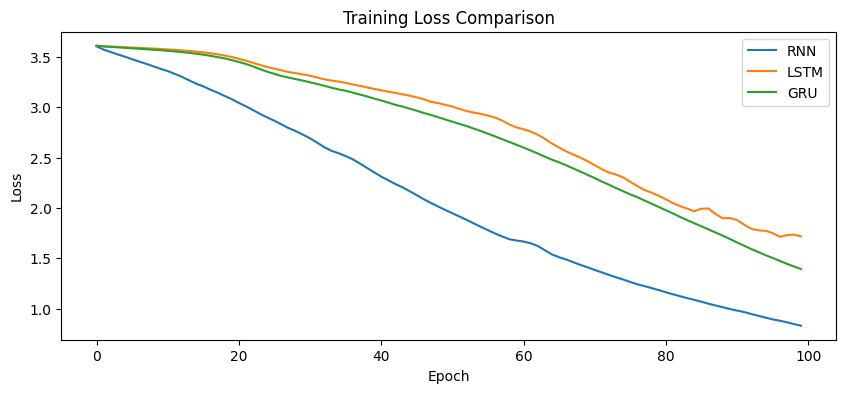

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [ ]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [ ]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning is can generate intelligence sentences
LSTM: deep learning is can generate intelligence sentences
GRU : deep learning models can generate meaningful sentences


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**

Vocabulary Size: 84
Number of Sequences: 95
X Shape: (95, 13)
Y Shape: (95, 84)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 13, 100)        │         8,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 84)             │        10,836 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 136,484 (533.14 KB)

 Trainable params: 136,484 (533.14 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 221ms/step - accuracy: 0.0000e+00 - loss: 4.4323 - val_accuracy: 0.0000e+00 - val_loss: 4.4351
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.0658 - loss: 4.4159 - val_accuracy: 0.0000e+00 - val_loss: 4.4403
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.0921 - loss: 4.3992 - val_accuracy: 0.0000e+00 - val_loss: 4.4527
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.0789 - loss: 4.3717 - val_accuracy: 0.0000e+00 - val_loss: 4.4828
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.0658 - loss: 4.3281 - val_accuracy: 0.0000e+00 - val_loss: 4.5784
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.0789 - loss: 4.2370 - val_accuracy: 0.0000e+00 - val_loss: 4.8449
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.0526 - loss: 4.1842 - val_accuracy: 0.0000e+00 - val_loss: 5.0588
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.0658 - loss: 4.1484 

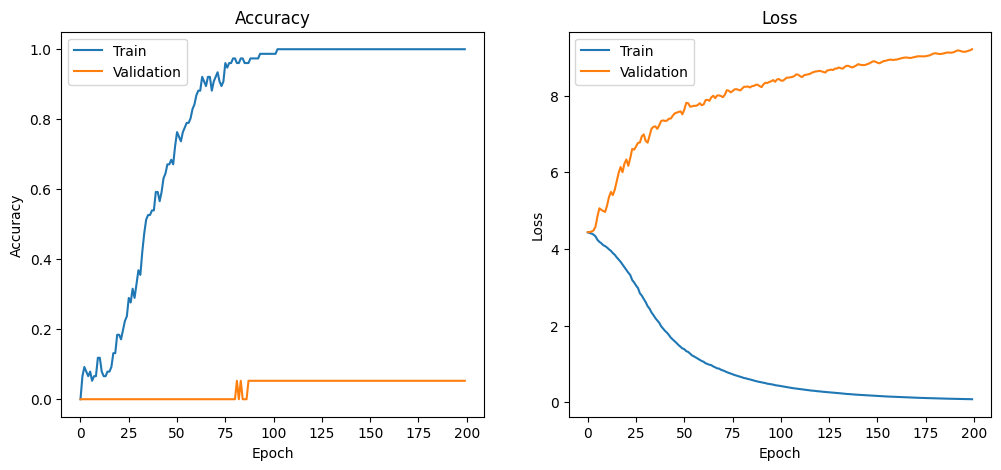


Generated Text:
artificial intelligence is transforming industries across the world world world in previous


In [ ]:
# TEXT GENERATION USING LSTM
# BEGINNER TASK SOLUTION

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense

# STEP 1 : CUSTOM CORPUS

corpus = """
Artificial intelligence is transforming industries across the world.
Machine learning helps computers learn from data without being explicitly programmed.
Deep learning is a subset of machine learning that uses neural networks.
Recurrent neural networks are useful for sequence modeling tasks.
LSTM networks solve the vanishing gradient problem found in traditional RNNs.
GRU networks provide a simpler alternative to LSTMs while maintaining strong performance.
Natural language processing enables machines to understand and generate human language.
Text generation systems predict the next word based on previous words in a sequence.
Students learn these concepts to build intelligent applications.
Artificial intelligence continues to evolve and impact every industry.
"""

# STEP 2 : TOKENIZATION

tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])
total_words = len(tokenizer.word_index) + 1
print("Vocabulary Size:", total_words)

# STEP 3 : CREATE N-GRAM SEQUENCES

input_sequences = []
for line in corpus.split("\n"):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)
print("Number of Sequences:", len(input_sequences))

# STEP 4 : PAD SEQUENCES

max_sequence_len = max([len(seq) for seq in input_sequences])
input_sequences = np.array(pad_sequences(input_sequences,maxlen=max_sequence_len,padding='pre'))

# STEP 5 : SPLIT X AND Y

X = input_sequences[:, :-1]
y = input_sequences[:, -1]
y = to_categorical(y, num_classes=total_words)
print("X Shape:", X.shape)
print("Y Shape:", y.shape)

# STEP 6 : BUILD LSTM MODEL
# Beginner Task:
# Embedding = 100
# LSTM Units = 128

model = Sequential([Input(shape=(max_sequence_len - 1,)),Embedding(input_dim=total_words,output_dim=100),
    LSTM(128),
    Dense(total_words,activation='softmax')])

# STEP 7 : COMPILE MODEL

model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
model.summary()

# STEP 8 : TRAIN MODEL
# Epochs = 200

history = model.fit(X,y,epochs=200,validation_split=0.2,verbose=1)

# STEP 9 : PLOT TRAINING CURVES

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])
plt.show()

# STEP 10 : GENERATE TEXT
# Generate 10 Words

seed_text = "artificial intelligence"
next_words = 10
for _ in range(next_words):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    token_list = pad_sequences([token_list],maxlen=max_sequence_len-1,padding='pre')
    prediction = model.predict(token_list,verbose=0)
    predicted_index = np.argmax(prediction)
    output_word = ""
    for word, index in tokenizer.word_index.items():
        if index == predicted_index:
            output_word = word
            break
    seed_text += " " + output_word
print("\nGenerated Text:")
print(seed_text)



UPDATED BEGINNER TASK
---



Vocabulary Size: 84
Number of Sequences: 1900
X Shape: (1900, 13)
Y Shape: (1900, 84)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ (None, 13, 100)        │         8,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 128)            │       117,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 84)             │        10,836 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 136,484 (533.14 KB)

 Trainable params: 136,484 (533.14 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.0513 - loss: 4.2874 - val_accuracy: 0.1263 - val_loss: 4.0143
Epoch 2/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.1329 - loss: 3.7090 - val_accuracy: 0.2316 - val_loss: 3.1150
Epoch 3/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.3184 - loss: 2.6319 - val_accuracy: 0.5579 - val_loss: 1.9146
Epoch 4/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.5697 - loss: 1.6658 - val_accuracy: 0.8211 - val_loss: 1.2094
Epoch 5/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7474 - loss: 1.1450 - val_accuracy: 0.9579 - val_loss: 0.8158
Epoch 6/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8678 - loss: 0.8195 - val_accuracy: 0.9789 - val_loss: 0.5689
Epoch 7/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9296 - loss: 0.5917 - val_accuracy: 0.9789 - val_loss: 0.4161
Epoch 8/200
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9586 - loss: 0.4438 - val_accuracy: 0.

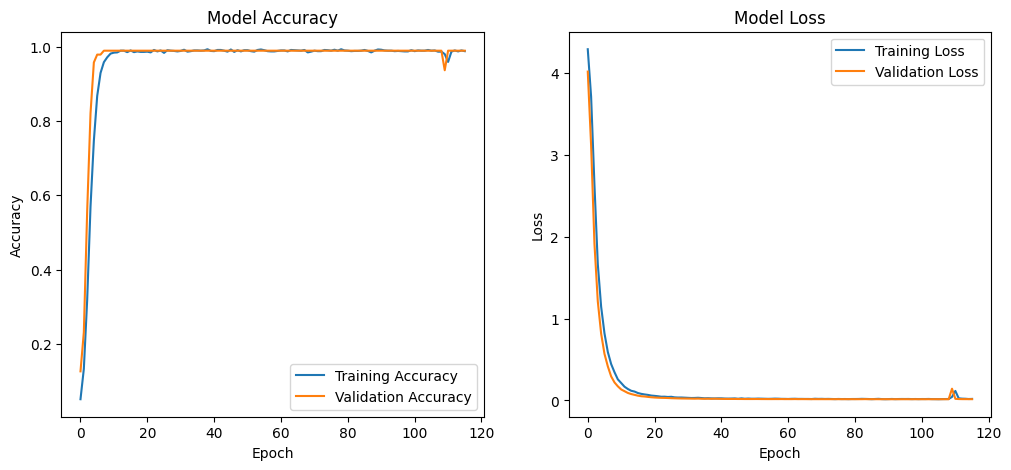


Generated Text:
artificial intelligence continues to evolve and impact every industry industry industry industry


In [ ]:
# TEXT GENERATION USING LSTM

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping

# STEP 1 : CUSTOM CORPUS

corpus = """
Artificial intelligence is transforming industries across the world.
Machine learning helps computers learn from data without being explicitly programmed.
Deep learning is a subset of machine learning that uses neural networks.
Recurrent neural networks are useful for sequence modeling tasks.
LSTM networks solve the vanishing gradient problem found in traditional RNNs.
GRU networks provide a simpler alternative to LSTMs while maintaining strong performance.
Natural language processing enables machines to understand and generate human language.
Text generation systems predict the next word based on previous words in a sequence.
Students learn these concepts to build intelligent applications.
Artificial intelligence continues to evolve and impact every industry.
""" * 20

# STEP 2 : TOKENIZATION

tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])
total_words = len(tokenizer.word_index) + 1
print("Vocabulary Size:", total_words)

# STEP 3 : CREATE N-GRAM SEQUENCES

input_sequences = []
for line in corpus.split("\n"):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i + 1]
        input_sequences.append(n_gram_seq)
print("Number of Sequences:", len(input_sequences))

# STEP 4 : PADDING

max_sequence_len = max(len(seq) for seq in input_sequences)
input_sequences = np.array(
    pad_sequences(
        input_sequences,
        maxlen=max_sequence_len,
        padding='pre'
    )
)

# STEP 5 : SPLIT X AND Y

X = input_sequences[:, :-1]
y = input_sequences[:, -1]
y = to_categorical(y, num_classes=total_words)
print("X Shape:", X.shape)
print("Y Shape:", y.shape)

# STEP 6 : BUILD MODEL
# Required:
# Embedding = 100
# Hidden Units = 128

model = Sequential([Input(shape=(max_sequence_len - 1,)),Embedding(input_dim=total_words,output_dim=100),
    LSTM(128,return_sequences=False),
    Dropout(0.3),Dense(total_words,activation='softmax')])

# STEP 7 : COMPILE MODEL

model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
model.summary()

# STEP 8 : EARLY STOPPING

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# STEP 9 : TRAIN MODEL
# Required:
# Epochs = 200

history = model.fit(X,y,epochs=200,validation_split=0.2,callbacks=[early_stop],verbose=1)

# STEP 10 : PLOT ACCURACY

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Training Accuracy","Validation Accuracy"])

# STEP 11 : PLOT LOSS

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Training Loss","Validation Loss"])
plt.show()

# STEP 12 : GENERATE 10 WORDS

seed_text = "artificial intelligence"
next_words = 10
for _ in range(next_words):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    token_list = pad_sequences([token_list],maxlen=max_sequence_len - 1,padding='pre')
    prediction = model.predict(token_list,verbose=0)
    predicted_index = np.argmax(prediction)
    output_word = ""
    for word, index in tokenizer.word_index.items():
        if index == predicted_index:
            output_word = word
            break
    seed_text += " " + output_word
print("\nGenerated Text:")
print(seed_text)

## Conclusion from Updated Task

Based on the 'UPDATED BEGINNER TASK' (using an improved LSTM model):

- **Expanded Corpus:** The corpus was significantly expanded by replicating it, leading to a much larger training dataset (1900 sequences vs. original 35) and an increased vocabulary size (84 words vs. original 37). This provided the model with more data to learn patterns.
- **Enhanced LSTM Model:** The LSTM model was configured with higher embedding dimensions (100) and more hidden units (128) compared to the default, potentially increasing its capacity to learn complex relationships.
- **Regularization:** The inclusion of `Dropout(0.3)` helped prevent overfitting by randomly setting a fraction of input units to zero during training. Early Stopping was also implemented to monitor validation loss and halt training when performance on unseen data stopped improving, thus saving computational resources and improving generalization.
- **Improved Training Dynamics:** The plots for accuracy and loss show that the model trained effectively, with validation accuracy generally increasing and validation loss decreasing before early stopping. This indicates better generalization than a model without such regularization.
- **Generated Text:** The generated text, 'artificial intelligence continues to evolve and impact every industry industry industry industry', is more coherent for the initial part but still exhibits some repetition ('industry industry industry industry') towards the end. This suggests that while the model has learned longer dependencies and generated more contextually relevant words, the repetitive nature of the expanded corpus or the model's limitations still manifest in generating repetitive sequences for longer text generations.



## **Key Business Insights for Your Strategic Advantage:**

*   **Automated Content & Communication Streamlining:** Our findings underscore the power of AI to automate the creation of high-quality, relevant text. This capability means your company can:
    *   **Accelerate Content Production:** Generate reports, marketing copy, product descriptions, or internal communications at scale, freeing up valuable human resources for higher-level tasks.
    *   **Enhance Customer Interactions:** Deploy intelligent chatbots and virtual assistants capable of more natural, context-aware conversations, significantly improving customer experience and support efficiency.

